# K Nearest Neighbors Project 

## Import Libraries
**Import pandas,seaborn, and the usual libraries.**

In [4]:
import pandas as pd

## Get the Data
** Read the 'KNN_Project_Data csv file into a dataframe **

In [5]:
df = pd.read_csv("KNN_Project_Data")

**Check the head of the dataframe.**

In [6]:
df.head()

,XVPM,GWYH,TRAT,TLLZ,IGGA,HYKR,EDFS,GUUB,MGJM,JHZC,TARGET CLASS
0,1636.670614,817.988525,2565.995189,358.347163,550.417491,1618.870897,2147.641254,330.727893,1494.878631,845.136088,0
1,1013.402760,577.587332,2644.141273,280.428203,1161.873391,2084.107872,853.404981,447.157619,1193.032521,861.081809,1
2,1300.035501,820.518697,2025.854469,525.562292,922.206261,2552.355407,818.676686,845.491492,1968.367513,1647.186291,1
3,1059.347542,1066.866418,612.000041,480.827789,419.467495,685.666983,852.867810,341.664784,1154.391368,1450.935357,0
4,1018.340526,1313.679056,950.622661,724.742174,843.065903,1370.554164,905.469453,658.118202,539.459350,1899.850792,0


# EDA

Since this data is artificial, we'll just do a large pairplot with seaborn.

**Use seaborn on the dataframe to create a pairplot with the hue indicated by the TARGET CLASS column.**

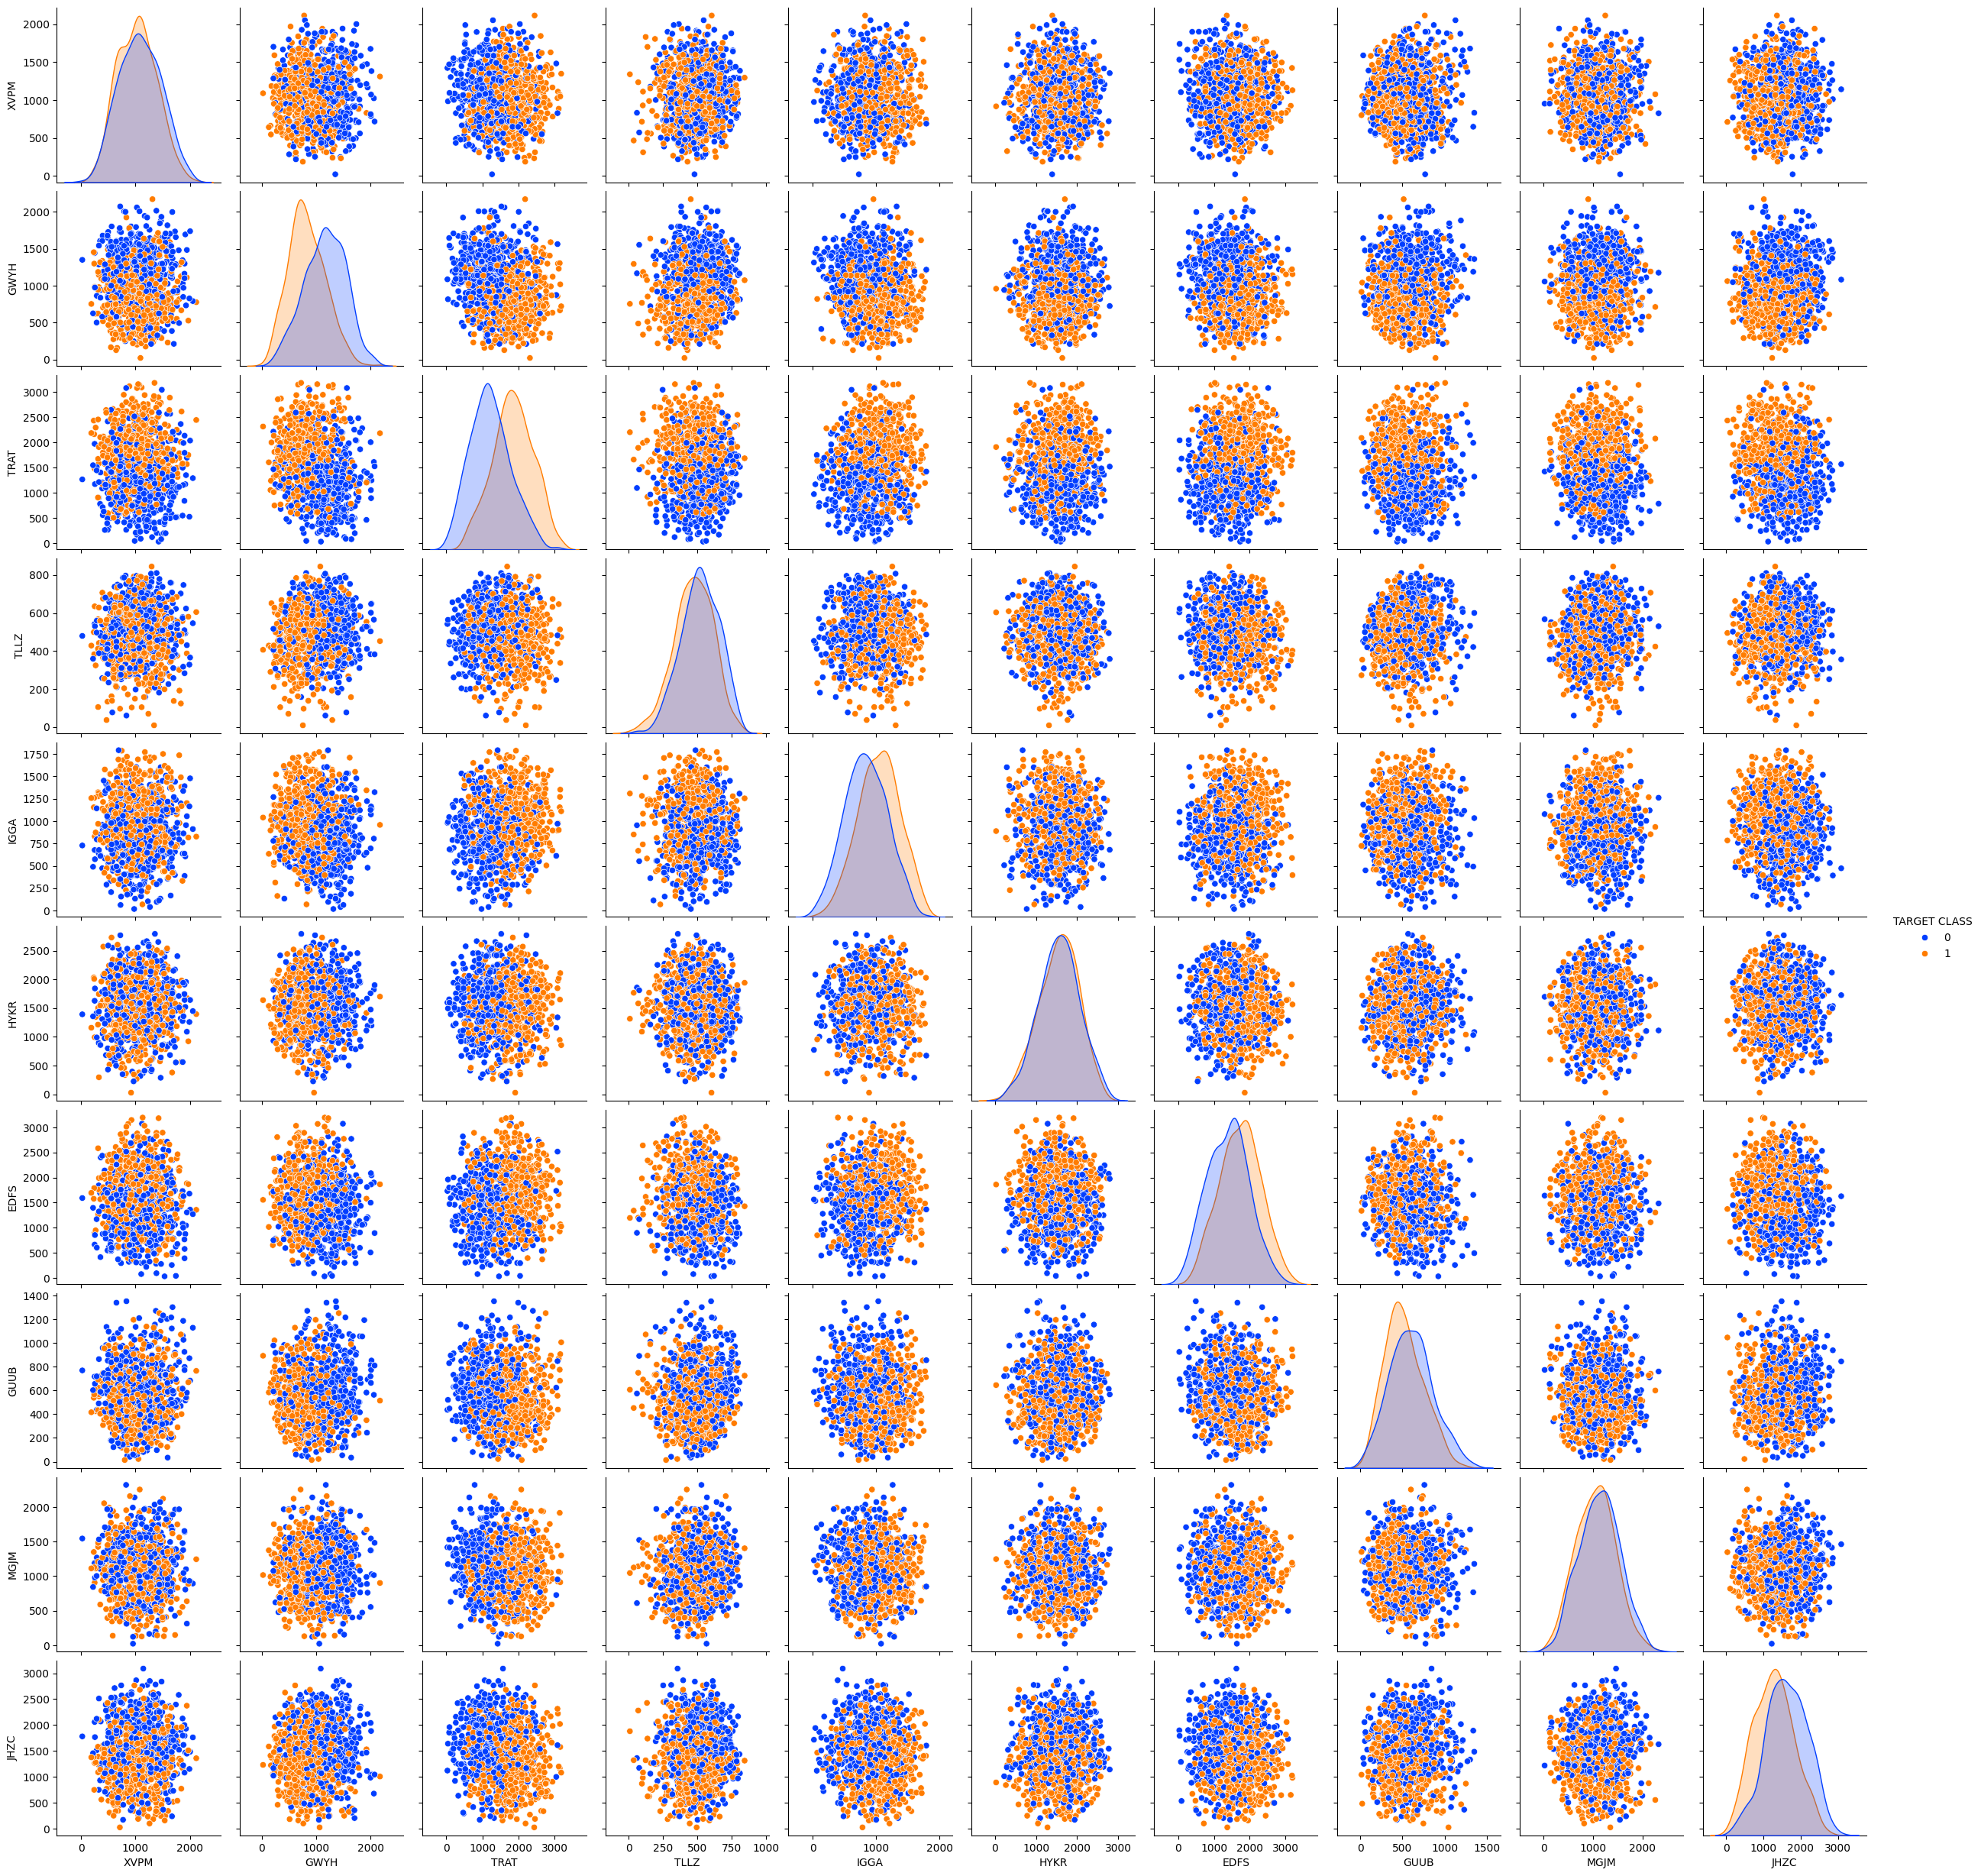

In [7]:
import seaborn as sns
sns.pairplot(df, hue='TARGET CLASS', palette='bright')

# Train Test Split

**Use train_test_split to split your data into a training set and a testing set.**

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X = df.drop('TARGET CLASS', axis=1)
y = df['TARGET CLASS']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

# Standardize the Variables

Time to standardize the variables.

** Import StandardScaler from Scikit learn.**

In [11]:
from sklearn.preprocessing import StandardScaler

** Create a StandardScaler() object called scaler.**

In [12]:
scaler = StandardScaler()

** Fit scaler to the features.**

In [13]:
scaler.fit(X_train)

StandardScaler()

**Use the .transform() method to transform the features to a scaled version.**

In [14]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
df_scaled = pd.DataFrame(X_train_scaled, columns=df.columns[:-1])
df_scaled

,XVPM,GWYH,TRAT,TLLZ,IGGA,HYKR,EDFS,GUUB,MGJM,JHZC
0,-2.131207,-0.029876,-0.070741,1.011517,-0.332789,-1.132088,-1.079541,0.190234,-0.459044,-0.293330
1,0.551623,-1.708943,0.268688,0.458320,1.216487,-0.080555,0.934718,-0.215476,0.294657,1.362008
2,0.492807,-1.186567,0.283564,-0.724657,-0.387366,-1.314568,1.201963,-1.494292,-0.505361,-0.628549
3,0.473814,0.376672,0.200586,0.409384,-1.979776,1.228047,1.800494,0.634393,1.210954,-0.144551
4,-0.025188,-0.425766,1.465413,0.357559,0.641439,0.316196,0.519274,-0.551063,-0.064037,-2.187418
...,...,...,...,...,...,...,...,...,...,...
695,1.252703,0.051112,-0.701502,-2.061033,-1.455385,-0.796466,1.872870,0.668110,0.346671,-1.100887
696,1.027748,2.175773,1.191766,0.168196,-0.385955,0.120474,-0.818751,1.940825,-1.546376,0.030515
697,0.909669,0.543962,-1.374030,0.405591,0.900237,0.382651,-1.318710,-0.828506,0.904070,1.345334
698,-1.054751,0.290368,-1.539001,0.613186,-0.539894,-1.577238,-0.669589,-0.887908,0.395469,-0.088694


# Using KNN

**Import KNeighborsClassifier from scikit learn.**

In [18]:
from sklearn.neighbors import KNeighborsClassifier

**Create a KNN model instance with n_neighbors=1**

In [19]:
knn = KNeighborsClassifier(n_neighbors=1)

**Fit this KNN model to the training data.**

In [20]:
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=1)

# Predictions and Evaluations
Let's evaluate our KNN model!

**Use the predict method to predict values using your KNN model and X_test.**

In [21]:
predictions = knn.predict(X_test_scaled)

** Create a confusion matrix and classification report.**

In [22]:
from sklearn.metrics import classification_report, confusion_matrix

In [23]:
print(confusion_matrix(y_test, predictions))

[[110  42]
 [ 41 107]]


In [24]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.73      0.72      0.73       152
           1       0.72      0.72      0.72       148

    accuracy                           0.72       300
   macro avg       0.72      0.72      0.72       300
weighted avg       0.72      0.72      0.72       300



# Choosing a K Value
Let's go ahead and use the elbow method to pick a good K Value!

** Create a for loop that trains various KNN models with different k values, then keep track of the error_rate for each of these models with a list. Refer to the lecture if you are confused on this step.**

In [25]:
error_rate = []

for i in range(1,40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    pred_i = knn.predict(X_test_scaled)
    error_rate.append(np.mean(pred_i != y_test))

**Now create the following plot using the information from your for loop.**

Text(0, 0.5, 'Error Rate')

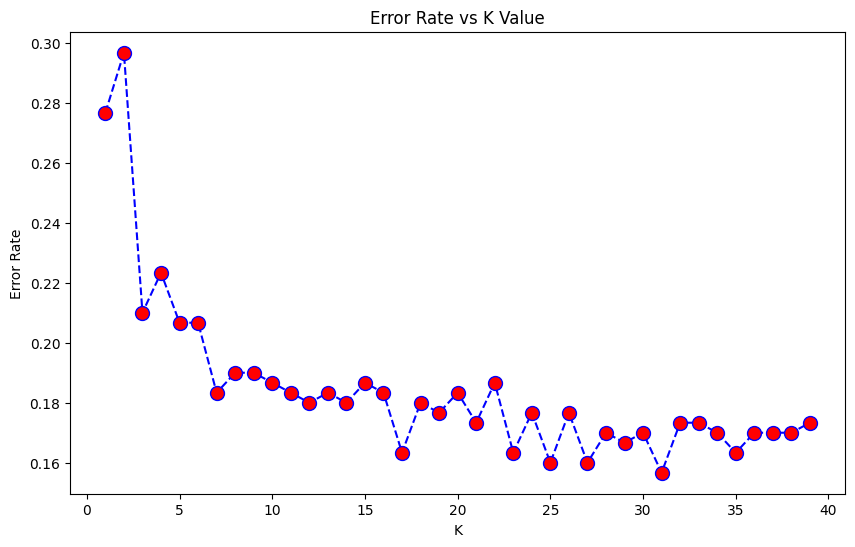

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 40), error_rate, color='blue', linestyle='dashed',marker='o', markerfacecolor='red', markersize=10)
plt.title("Error Rate vs K Value")
plt.xlabel("K")
plt.ylabel("Error Rate")

In [27]:
min_error = min(error_rate)
best_k = error_rate.index(min_error) + 1  # +1 because k starts at 1

print(f"\nBest K: {best_k} with lowest Error Rate: {min_error}")


Best K: 31 with lowest Error Rate: 0.15666666666666668


## Retrain with new K Value

**Retrain your model with the best K value (up to you to decide what you want) and re-do the classification report and the confusion matrix.**

In [40]:
knn_bestK = KNeighborsClassifier(n_neighbors=17)
knn_bestK.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=17)

In [41]:
predictions = knn_bestK.predict(X_test_scaled)

In [42]:
print(confusion_matrix(y_test, predictions))

[[125  27]
 [ 22 126]]


Interpretation:

* <b>True Negatives (TN)</b> = 125 Predicted class 0 and actually class 0
* <b>False Positives (FP)</b> = 27 Predicted class 1 but actually class 0
* <b>False Negatives (FN)</b> = 22 Predicted class 0 but actually class 1
* <b>True Positives: (TP)</b> = 126 Predicted class 1 and actually class 1

In [43]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.85      0.82      0.84       152
           1       0.82      0.85      0.84       148

    accuracy                           0.84       300
   macro avg       0.84      0.84      0.84       300
weighted avg       0.84      0.84      0.84       300



<div style="display: inline-block; text-align: left">

|Metric|Class 0|Class 1|Explanation|
|:--------|:--------|:--------|:--------|
|Precision|	0.85|	0.82|	Out of all predicted as this class, % correct|
|Recall|	0.82|	0.85|	Out of all actual in this class, % correctly found|
|F1-score|	0.84|	0.84|	Harmonic mean of precision and recall (balance)|
|Support|	152|	148|	Number of true instances in each class|

</div>